# Day 37 — Elastic Net: The Best of Both Worlds

### Two tools, two weaknesses
| | Strength | Weakness |
|---|---|---|
| **Ridge** | Stable; shares weight across correlated features | Never removes useless features |
| **Lasso** | Removes useless features | With correlated features, keeps one at random and drops the rest |

**Elastic Net** uses *both* penalties at once.

### In this notebook
1. 🧪 An experiment where Ridge and Lasso both struggle
2. 🎛️ The `l1_ratio` dial between Ridge and Lasso
3. 📐 The shape of the Elastic Net penalty
4. 🏆 Final showdown on real data: Linear vs Ridge vs Lasso vs Elastic Net
5. 🧭 Which one should I use?

> 📖 Theory: [`theory.md`](theory.md) · 🎨 *Visualization only* cells are collapsed: you only need their plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

---
## 1. 🧪 The experiment: correlated features

Imagine predicting house price from `area_sqft`, `area_sqm` and `num_tiles`: three features that measure **almost
the same thing**. We simulate exactly that:
- `x1`, `x2`, `x3`: three noisy copies of the same hidden signal (correlation ≈ 0.99)
- `noise1`, `noise2`, `noise3`: pure noise, with no relation to y
- **Truth:** y depends only on the hidden signal, so the "fair" answer is equal weights on x1–x3 and **0** on the noise.

In [2]:
rng = np.random.default_rng(0)
n = 200
signal = rng.normal(size=n)

Xc = pd.DataFrame({
    'x1': signal + 0.05 * rng.normal(size=n),
    'x2': signal + 0.05 * rng.normal(size=n),
    'x3': signal + 0.05 * rng.normal(size=n),
    'noise1': rng.normal(size=n),
    'noise2': rng.normal(size=n),
    'noise3': rng.normal(size=n),
})
yc = 3 * signal + rng.normal(size=n)

Xc[['x1', 'x2', 'x3']].corr().round(3)

,x1,x2,x3
x1,1.000,0.997,0.998
x2,0.997,1.000,0.997
x3,0.998,0.997,1.000


> ✍️ **Core code: learn this.** Fit all four models on the same data.

In [3]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1),
    'Lasso (alpha=0.2)': Lasso(alpha=0.2),
    'ElasticNet (alpha=0.2, l1_ratio=0.5)': ElasticNet(alpha=0.2, l1_ratio=0.5),
}
coefs = pd.DataFrame({name: m.fit(Xc, yc).coef_ for name, m in models.items()}, index=Xc.columns).T.round(2) + 0.0   # + 0.0 turns -0.0 into 0.0
coefs

,x1,x2,x3,noise1,noise2,noise3
LinearRegression,-0.82,1.69,2.18,-0.07,-0.02,0.04
Ridge (alpha=1),0.45,1.23,1.37,-0.08,-0.02,0.03
Lasso (alpha=0.2),0.00,1.22,1.62,0.00,0.00,0.00
"ElasticNet (alpha=0.2, l1_ratio=0.5)",0.90,0.97,0.98,0.00,0.00,0.00


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

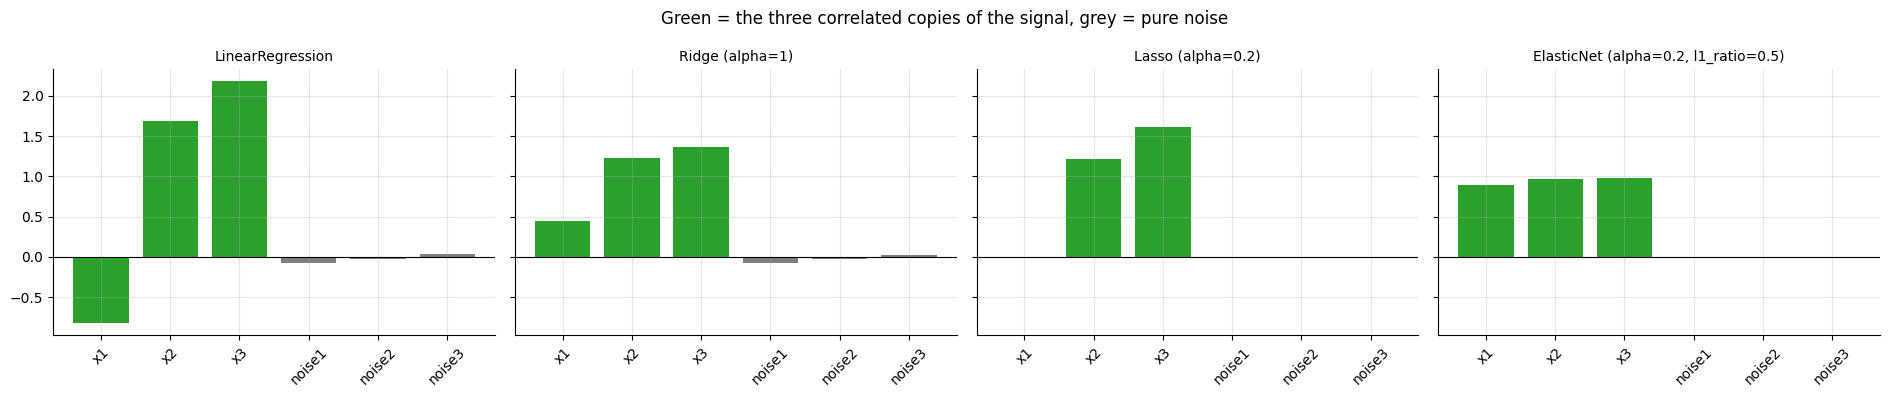

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4), sharey=True)
colors = ['tab:green'] * 3 + ['tab:gray'] * 3
for ax, (name, row) in zip(axes, coefs.iterrows()):
    ax.bar(row.index, row.values, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Green = the three correlated copies of the signal, grey = pure noise', fontsize=12)
plt.tight_layout()
plt.show()

What each model did:

| Model | Signal copies (x1–x3) | Noise features | Verdict |
|---|---|---|---|
| Linear Regression | wild, one even **negative** | small but non-zero | ❌ unstable: tiny data changes would flip these weights |
| Ridge | shared, but uneven | **kept** (non-zero) | ⚠️ stable, but no feature selection |
| Lasso | **dropped x1** arbitrarily | removed | ⚠️ selects, but throws away a perfectly good feature |
| **Elastic Net** | **shared almost equally** | **removed** | ✅ groups correlated features *and* selects |

This **grouping effect** is the reason Elastic Net exists.

---
## 2. 🎛️ The `l1_ratio` dial

$$
\text{Loss} = \frac{1}{2n}\sum (y_i - \hat y_i)^2 \;+\; \alpha\cdot\texttt{l1\_ratio}\sum\lvert w_j\rvert \;+\; \frac{\alpha\,(1-\texttt{l1\_ratio})}{2}\sum w_j^2
$$

- `alpha`: **how much** total penalty
- `l1_ratio`: **what kind** of penalty, from 0 = pure Ridge to 1 = pure Lasso

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

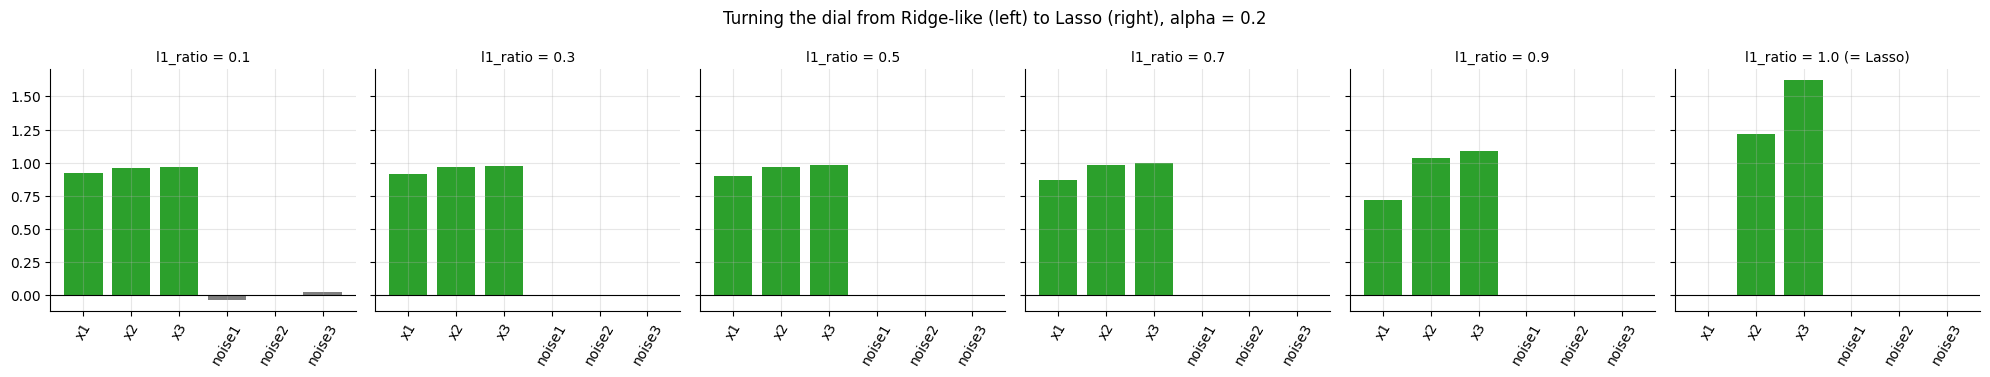

In [5]:
ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
fig, axes = plt.subplots(1, len(ratios), figsize=(20, 3.8), sharey=True)
for ax, r in zip(axes, ratios):
    c = ElasticNet(alpha=0.2, l1_ratio=r).fit(Xc, yc).coef_
    ax.bar(Xc.columns, c, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    label = ' (= Lasso)' if r == 1 else ''
    ax.set_title(f'l1_ratio = {r}{label}', fontsize=10)
    ax.tick_params(axis='x', rotation=60)
plt.suptitle('Turning the dial from Ridge-like (left) to Lasso (right), alpha = 0.2', fontsize=12)
plt.tight_layout()
plt.show()

- **Small `l1_ratio` (Ridge-like):** the three copies share the weight, but the noise features keep small non-zero weights.
- **Middle values:** noise features are removed *and* the copies still share the weight. This is the sweet spot.
- **`l1_ratio = 1` (pure Lasso):** one signal copy is dropped as well.

The Ridge part keeps the correlated group together; the Lasso part removes the noise.

---
## 3. 📐 The shape of the penalty

Ridge = circle, Lasso = diamond. Elastic Net is in between: a **diamond with rounded sides**. It keeps the corners (so it
can still produce zeros) but its curved edges make it behave like Ridge for correlated features.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

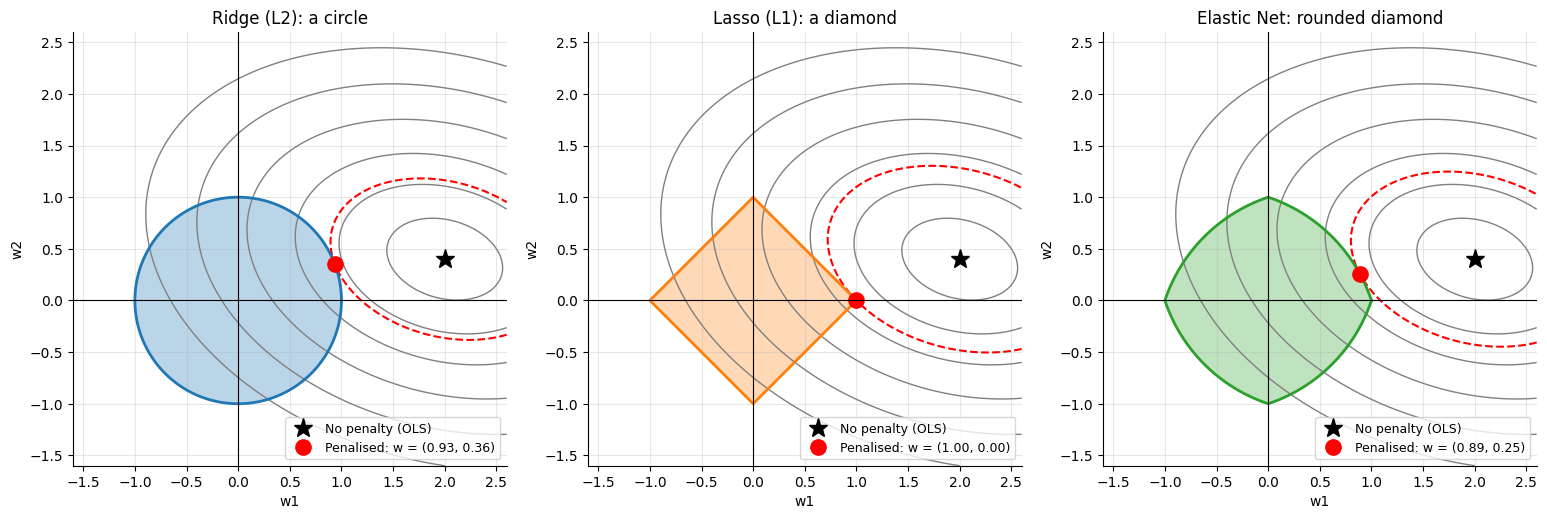

In [6]:
# A 2-feature problem: the error (RSS) surface is a bowl whose lowest point is the OLS solution
A = np.array([[1.0, 0.3], [0.3, 2.0]])
w_ols = np.array([2.0, 0.4])
rss = lambda w1, w2: (A[0, 0] * (w1 - w_ols[0])**2 + 2 * A[0, 1] * (w1 - w_ols[0]) * (w2 - w_ols[1])
                      + A[1, 1] * (w2 - w_ols[1])**2)

def boundary(radius_fn, n=4000):
    th = np.linspace(0, 2 * np.pi, n)
    d = np.c_[np.cos(th), np.sin(th)]
    r = np.array([radius_fn(v) for v in d])
    return d * r[:, None]

def best_on(points):
    return points[np.argmin(rss(points[:, 0], points[:, 1]))]

shapes = [('Ridge (L2): a circle', lambda d: 1.0, 'tab:blue'), ('Lasso (L1): a diamond', lambda d: 1.0 / (abs(d[0]) + abs(d[1])), 'tab:orange'), ('Elastic Net: rounded diamond', lambda d, rho=0.5: (-rho * (abs(d[0]) + abs(d[1])) + np.sqrt((rho * (abs(d[0]) + abs(d[1])))**2 + 4 * (1 - rho))) / (2 * (1 - rho)), 'tab:green')]

g = np.linspace(-1.6, 2.6, 300)
G1, G2 = np.meshgrid(g, g)
fig, axes = plt.subplots(1, len(shapes), figsize=(5.2 * len(shapes), 5))
axes = np.atleast_1d(axes)
for ax, (name, fn, color) in zip(axes, shapes):
    pts = boundary(fn)
    w = best_on(pts)
    ax.contour(G1, G2, rss(G1, G2), levels=[0.3, 1, 2, 3.5, 5.5, 8], colors='gray', linewidths=1)
    ax.contour(G1, G2, rss(G1, G2), levels=[rss(*w)], colors='red', linestyles='--', linewidths=1.5)
    ax.fill(pts[:, 0], pts[:, 1], color=color, alpha=0.3)
    ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=2)
    ax.plot(*w_ols, 'k*', markersize=14, label='No penalty (OLS)')
    ax.plot(*w, 'o', color='red', markersize=11, label=f'Penalised: w = ({w[0]:.2f}, {w[1]:.2f})')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_aspect('equal')
    ax.set_xlim(-1.6, 2.6)
    ax.set_ylim(-1.6, 2.6)
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(name)
    ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Elastic Net's solution lands **between** the other two: $w_2$ is pulled down further than with Ridge (0.25 vs 0.36),
but not all the way to 0 as with Lasso. Its corners are still there, so with a stronger penalty, or with useless features
like the noise columns in Section 1, it does produce exact zeros.

---
## 4. 🏆 Final showdown on real data

In [7]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
features = X.columns

> ✍️ **Core code: learn this.** Every regularised model comes with a `...CV` version that tunes its hyperparameters by cross-validation.

In [8]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

final_models = {
    'LinearRegression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas=np.logspace(-4, 3, 50)),
    'LassoCV': LassoCV(cv=5, random_state=0),
    'ElasticNetCV': ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0], cv=5, random_state=0),
}

rows = []
for name, model in final_models.items():
    model.fit(X_train, y_train)
    rows.append({'model': name,
                 'alpha': round(getattr(model, 'alpha_', 0), 4),
                 'l1_ratio': getattr(model, 'l1_ratio_', '-'),
                 'test R²': round(r2_score(y_test, model.predict(X_test)), 3),
                 'features used': int(np.sum(model.coef_ != 0))})
pd.DataFrame(rows)

,model,alpha,l1_ratio,test R²,features used
0,LinearRegression,0.0000,-,0.440,10
1,RidgeCV,0.0027,-,0.442,10
2,LassoCV,0.0541,-,0.438,7
3,ElasticNetCV,0.0541,1.0,0.438,7


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

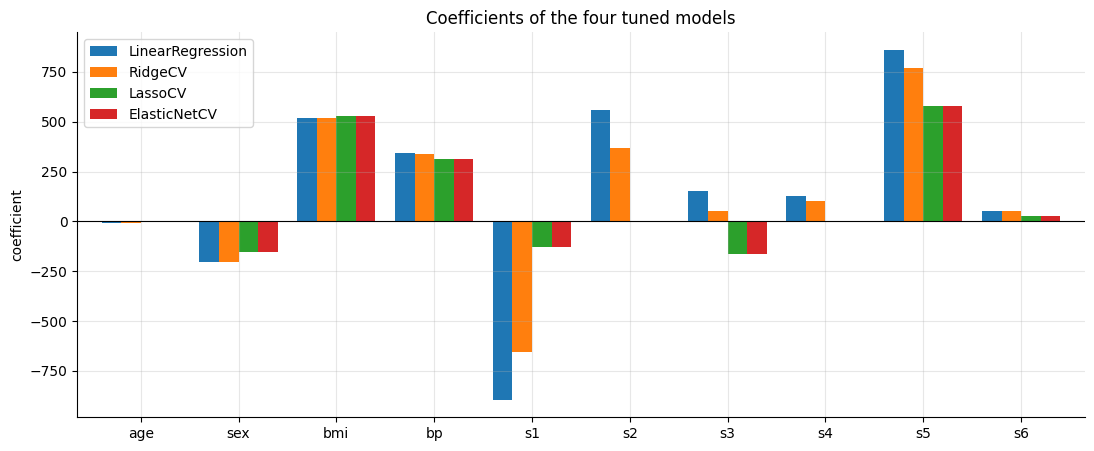

In [9]:
coef_table = pd.DataFrame({name: m.coef_ for name, m in final_models.items()}, index=features)
coef_table.plot(kind='bar', figsize=(13, 5), width=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Coefficients of the four tuned models')
plt.ylabel('coefficient')
plt.xticks(rotation=0)
plt.show()

**Reading the result honestly:**
- All four models land at almost the same test R² (≈ 0.44). On this small, already-clean dataset Linear Regression is not badly overfit, so regularisation has little room to help accuracy.
- The regularised models get there with **smaller, more stable weights**, and Lasso / Elastic Net also with **fewer features**.
- `ElasticNetCV` may well choose `l1_ratio = 1`, i.e. pure Lasso. That is a legitimate result: Elastic Net *searches over*
  Ridge-like and Lasso-like behaviour and picks what cross-validation prefers. Its advantage shows up most when there are
  **many correlated features** (Section 1), as in genomics, text and sensor data.

---
## 5. 🧭 Which one should I use?

```
Start: Linear Regression overfits, or you have many features
│
├─ Do you need feature selection (a smaller, interpretable model)?
│     ├─ No  ──────────────────────────────────► Ridge
│     └─ Yes
│          ├─ Are there groups of correlated features? ─► Elastic Net
│          └─ No / not sure ───────────────────────────► Lasso (or let ElasticNetCV decide)
│
└─ More features than samples (p > n)? ─────────────► Elastic Net
```

**When unsure:** use `ElasticNetCV` with a range of `l1_ratio` values. It contains Ridge-like and Lasso as special cases.

---
## 🧠 Quick check

<details><summary>1. What problem does Elastic Net solve that Lasso doesn't?</summary>

With correlated features, Lasso keeps one arbitrarily; Elastic Net keeps the group together and shares the weight (grouping effect).
</details>

<details><summary>2. What do `alpha` and `l1_ratio` control?</summary>

`alpha`: the total amount of regularisation. `l1_ratio`: the mix, from 0 (Ridge) to 1 (Lasso).
</details>

<details><summary>3. ElasticNetCV picked l1_ratio = 1. What does that mean?</summary>

Cross-validation preferred pure Lasso for this data; the model is equivalent to Lasso.
</details>

## 🎓 The whole regularisation chapter in one table

| | Linear | Ridge | Lasso | Elastic Net |
|---|---|---|---|---|
| Penalty | none | $\alpha\sum w^2$ | $\alpha\sum\lvert w\rvert$ | both |
| Shrinks weights | ❌ | ✅ | ✅ | ✅ |
| Exact zeros (feature selection) | ❌ | ❌ | ✅ | ✅ |
| Handles correlated features well | ❌ | ✅ | ⚠️ picks one | ✅ |
| Hyperparameters | – | `alpha` | `alpha` | `alpha`, `l1_ratio` |
| sklearn (tuned) | `LinearRegression` | `RidgeCV` | `LassoCV` | `ElasticNetCV` |